In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
my_file = Path('mymoviedb.csv')

In [3]:
from logging import exception
if my_file.is_file() == False:
  !wget 'https://raw.githubusercontent.com/ChetanParmarHQ/Netflix-Movie-Analysis-Python/refs/heads/main/mymoviedb.csv'
try:
  df = pd.read_csv('mymoviedb.csv', lineterminator = '\n')
except Exception as e:
  print(e)

--2026-04-02 12:50:10--  https://raw.githubusercontent.com/ChetanParmarHQ/Netflix-Movie-Analysis-Python/refs/heads/main/mymoviedb.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4208091 (4.0M) [text/plain]
Saving to: ‘mymoviedb.csv’

mymoviedb.csv       100%[===================>]   4.01M  --.-KB/s    in 0.07s   

2026-04-02 12:50:10 (58.7 MB/s) - ‘mymoviedb.csv’ saved [4208091/4208091]



In [4]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [6]:
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


#Exploration Summary


*   We have dataframe consisting of 9827 rows and 9 columns.
*   Our dataset looks a bit tidy with no NaNs nor duplicated values.
*   Release_Date column needs to be casted into date time and to extract only the year value.
*   Overview, Original_Language and Poster_Url wouldn't be so useful during analytis, so we'll drop them.
*   There are noticable outliners in Popularity Colum
*   Vote_Average better be categorised for proper analysis.
*   Genre column has comma seperated values and white spaces that needs to be handled and casted into category.


In [9]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[ns]


In [10]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [11]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Dropping the Columns

In [12]:
cols = ['Overview', 'Original_Language', 'Poster_Url']

In [13]:
df.drop(cols, axis = 1, inplace = True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

**Categorizing `Vote_Average` column**

We would cut the `Vote_Average` values and make 4 categories:  `popular` `average` `below_avg` `not_popular`to describe more using `categorize_col()` function provided above.

In [14]:
def categorize_col(df, col, labels):

  edges = [df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']]

  df[col] = pd.cut(df[col], edges, labels = labels, duplicates = 'drop')
  return df

In [15]:
labels = ['not_popular', 'below_avg', 'average', 'popular']

categorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()


['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [16]:
df['Vote_Average'].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
average,2412
below_avg,2398


In [17]:
df.dropna(inplace = True) # df = df.dropn()

df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [18]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


We'd split genres into a list and then explode our datframe to have only one genre per row for each movie

In [19]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop = True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [20]:
df['Genre'].unique()

array(['Action', 'Adventure', 'Science Fiction', 'Crime', 'Mystery',
       'Thriller', 'Animation', 'Comedy', 'Family', 'Fantasy', 'War',
       'Horror', 'Drama', 'Music', 'Romance', 'Western', 'History',
       'TV Movie', 'Documentary'], dtype=object)

In [21]:
#casting column in category

df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [23]:
df.nunique()

,0
Release_Date,100
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,19


#Data Visualization

In [24]:
sns.set_style('whitegrid')

**1. What is the most frequent genre of movies released on Netflix?**

In [25]:
df['Genre'].describe()

,Genre
count,25552
unique,19
top,Drama
freq,3715


In [26]:
a = ((df['Genre'] == 'Drama').sum() / df['Genre'].count() * 100).round(2)

print('Drama genre has appeared more then', a,'% of times amoung 19 other genre')

Drama genre has appeared more then 14.54 % of times amoung 19 other genre


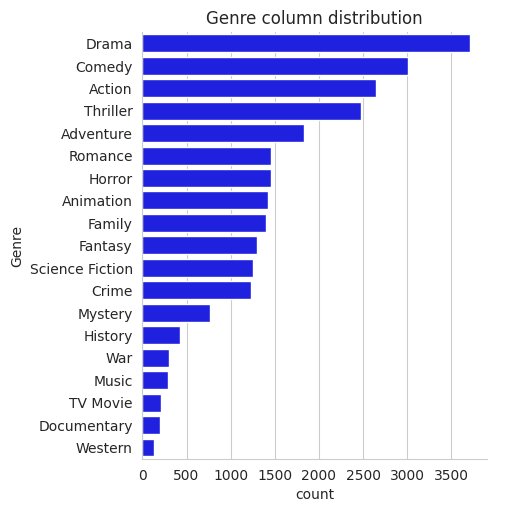

In [27]:
sns.catplot(y = 'Genre', data = df, kind = 'count', order = df['Genre'].value_counts().index, color = 'blue')

plt.title("Genre column distribution")
plt.show()

**2. Which genre has highest votes in vote avg column?**

In [28]:
print(df['Vote_Average'].value_counts())

x = (df['Vote_Average'] == 'popular').sum()
y = ((df['Vote_Average'] == 'popular').sum() / df['Vote_Average'].count() * 100).round(2)


Vote_Average
average        6613
popular        6520
below_avg      6348
not_popular    6071
Name: count, dtype: int64


In [29]:
print('we have', y,'% of our dataset with popular votes (', x,').')

we have 25.52 % of our dataset with popular votes ( 6520 ).


In [30]:
b = df[df['Vote_Average'] == 'popular']
print(b['Genre'].value_counts().head(1))
z = ((b['Genre'].value_counts().head(1)).sum() / x * 100).round(2)

Genre
Drama    1308
Name: count, dtype: int64


In [31]:
print('Drama again gets the highest popularity amoung fans by having more than', z,'% of popular movies popularities.')

Drama again gets the highest popularity amoung fans by having more than 20.06 % of popular movies popularities.


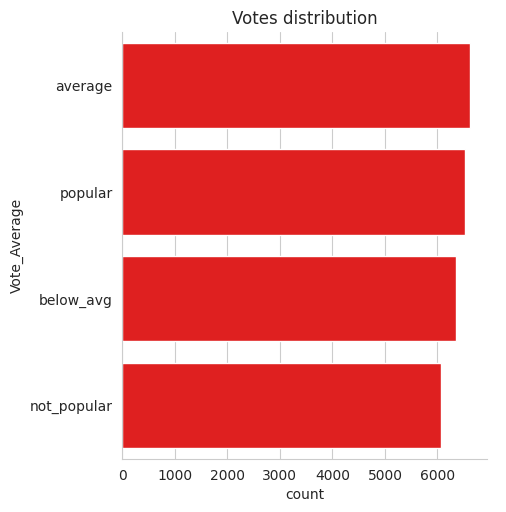

In [32]:
sns.catplot(y = 'Vote_Average', data = df, kind = 'count', order = df['Vote_Average'].value_counts().index, color ='red')
plt.title("Votes distribution")
plt.show()

**3. What movie got the highest popularity? what's its genre?**

In [33]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


**4. What movie got the lowest popularity? what's its genre?**

In [34]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


**5. Which year has the most filmmed movies?**

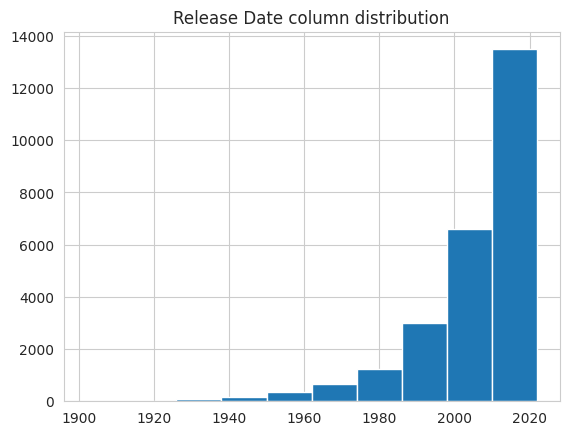

In [35]:
df['Release_Date'].hist()
plt.title("Release Date column distribution")
plt.show()

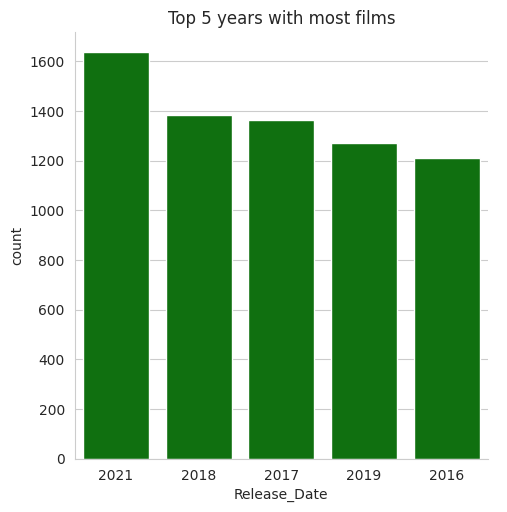

In [36]:
df['Release_Date'].value_counts().head()


sns.catplot(x = 'Release_Date', data = df, kind = 'count', order = df['Release_Date'].value_counts().head().index, color = 'green')
plt.title("Top 5 years with most films")
plt.show()

#**Conclusion**


**Q1. What is the most frequent genre of movies released on Netflix?**
- Drama genre is most frequent genre in our dataset and has appeared more then 14.54 % of times amoung 19 other genre.

**Q2. Which genre has highest votes in vote avg column?**
- we have 25.52 % of our dataset with popular votes ( 6520 ).Drama again gets the highest popularity amoung fans by having more than 20.06 % of popular movies popularities.

**Q3. What movie got the highest popularity? what's its genre?**
- Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Action, Adventure and Science Fiction.

**Q4. What movie got the lowest popularity? what's its genre?**
- 'The United States vs. Billie Holiday' and 'Threads' has the highest lowest rate in our dataset and it has genres of Music, Drama, History, War and Science Fiction.

**Q5. Which year has the most filmmed movies?**
- Year 2021 has the highest filmming rate in our dataset.